In [2]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.data.collector import F1DataCollector

%matplotlib inline

In [3]:
collector = F1DataCollector()
collector.load_session(2024, 'Bahrain Grand Prix')

laps = collector.session.laps
laps.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.4.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data f

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:01:37.510000,VER,1,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.266000,...,False,Red Bull Racing,0 days 00:59:59.911000,2024-03-02 15:03:42.342,12,1.0,False,,False,False
1,0 days 01:03:13.806000,VER,1,0 days 00:01:36.296000,2.0,1.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:41.661000,...,False,Red Bull Racing,0 days 01:01:37.510000,2024-03-02 15:05:19.941,1,1.0,False,,False,True
2,0 days 01:04:50.559000,VER,1,0 days 00:01:36.753000,3.0,1.0,NaT,NaT,0 days 00:00:30.999000,0 days 00:00:41.966000,...,False,Red Bull Racing,0 days 01:03:13.806000,2024-03-02 15:06:56.237,1,1.0,False,,False,True
3,0 days 01:06:27.206000,VER,1,0 days 00:01:36.647000,4.0,1.0,NaT,NaT,0 days 00:00:30.931000,0 days 00:00:41.892000,...,False,Red Bull Racing,0 days 01:04:50.559000,2024-03-02 15:08:32.990,1,1.0,False,,False,True
4,0 days 01:08:04.379000,VER,1,0 days 00:01:37.173000,5.0,1.0,NaT,NaT,0 days 00:00:31.255000,0 days 00:00:42.056000,...,False,Red Bull Racing,0 days 01:06:27.206000,2024-03-02 15:10:09.637,1,1.0,False,,False,True


/tmp/ipykernel_62384/2277087683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()


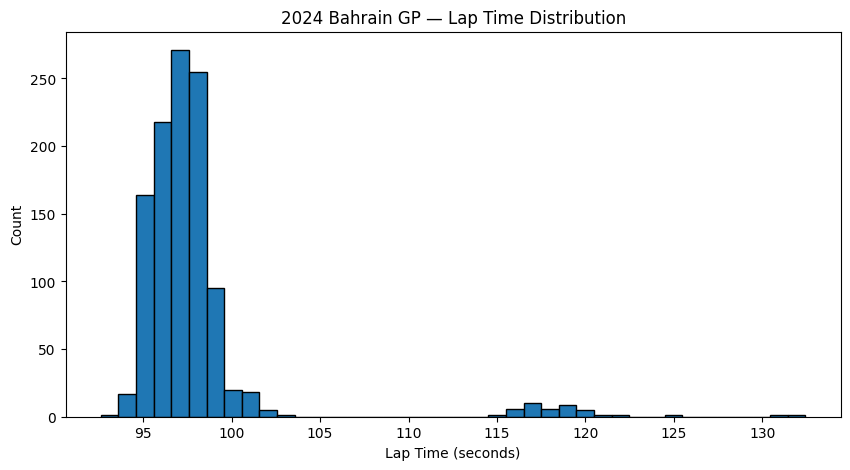

In [4]:
laps_clean = laps.dropna(subset=['LapTime'])
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()

plt.figure(figsize=(10, 5))
plt.hist(laps_clean['LapTimeSeconds'], bins=40, edgecolor='black')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Count')
plt.title('2024 Bahrain GP — Lap Time Distribution')
plt.show()

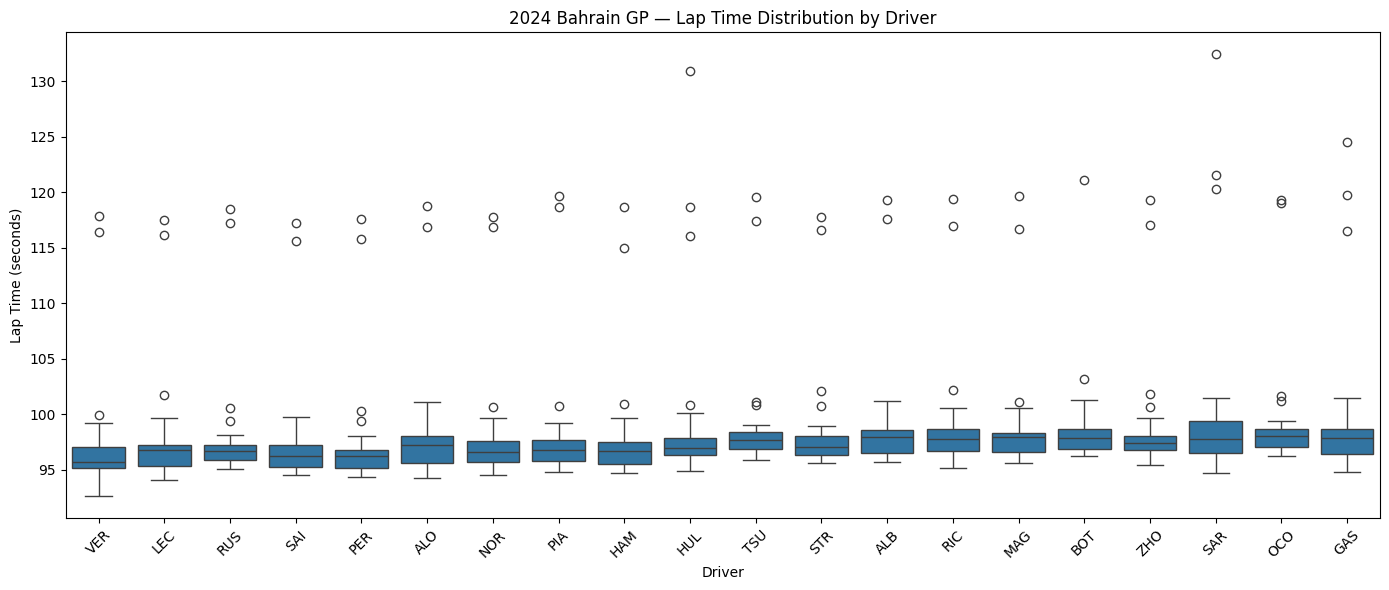

In [5]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='Driver', y='LapTimeSeconds', data=laps_clean)
plt.xlabel('Driver')
plt.ylabel('Lap Time (seconds)')
plt.title('2024 Bahrain GP — Lap Time Distribution by Driver')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

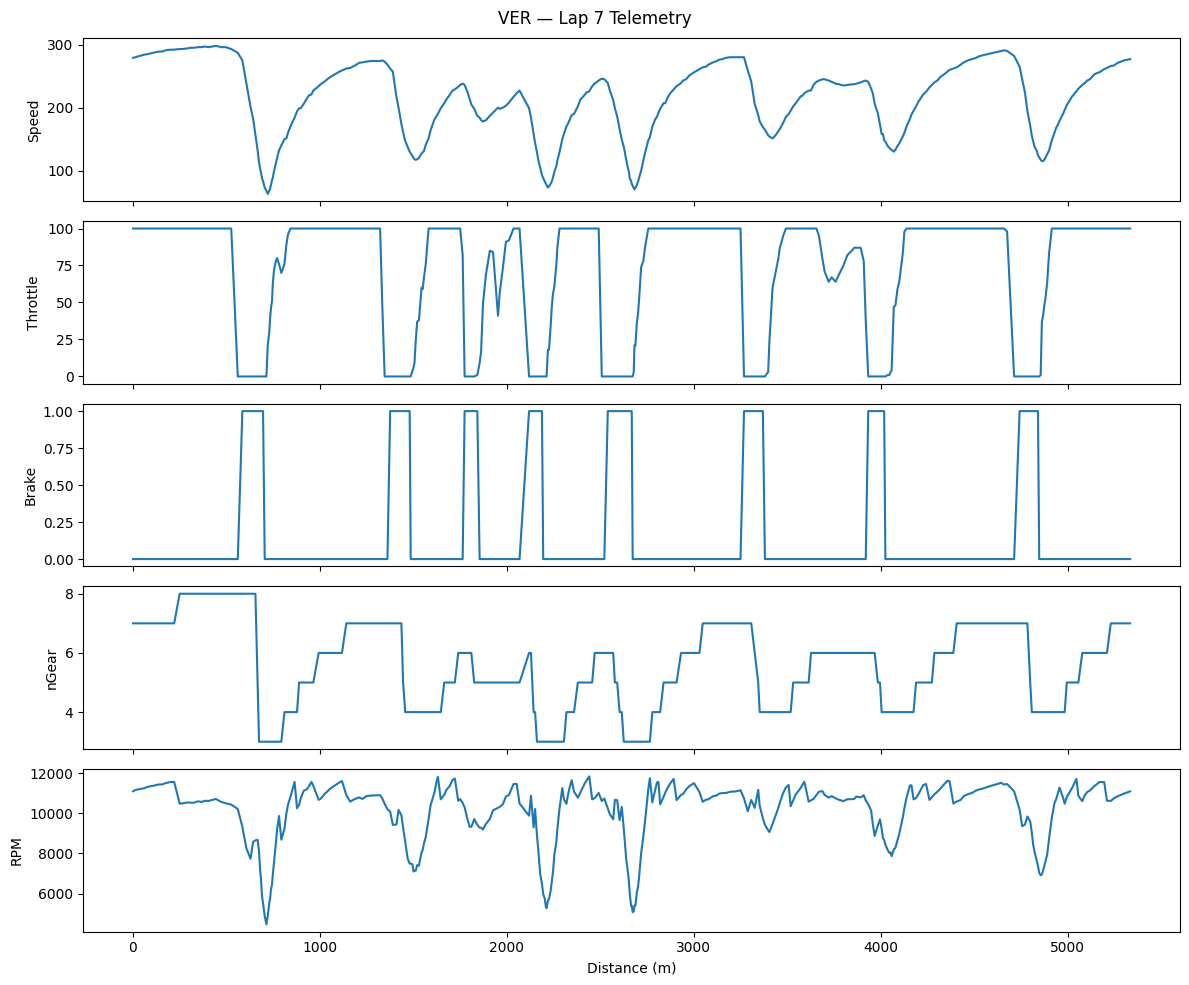

In [6]:
driver_laps = laps_clean[laps_clean['Driver'] == 'VER']
lap = driver_laps.iloc[5]  # pick a mid-race lap, not the first

tel = collector.get_telemetry(lap)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
signals = ['Speed', 'Throttle', 'Brake', 'nGear', 'RPM']

for ax, signal in zip(axes, signals):
    ax.plot(tel['Distance'], tel[signal])
    ax.set_ylabel(signal)

axes[-1].set_xlabel('Distance (m)')
fig.suptitle(f"VER — Lap {int(lap['LapNumber'])} Telemetry")
plt.tight_layout()
plt.show()

In [7]:
Q1 = laps_clean['LapTimeSeconds'].quantile(0.25)
Q3 = laps_clean['LapTimeSeconds'].quantile(0.75)
IQR = Q3 - Q1

laps_clean = laps_clean.copy()
laps_clean['is_anomaly'] = laps_clean['LapTimeSeconds'] > (Q3 + 1.5 * IQR)

total = len(laps_clean)
anomalies = laps_clean['is_anomaly'].sum()
print(f"Total laps: {total}")
print(f"Anomalous laps: {anomalies} ({100*anomalies/total:.1f}%)")

Total laps: 1107
Anomalous laps: 56 (5.1%)


5& class imbalance

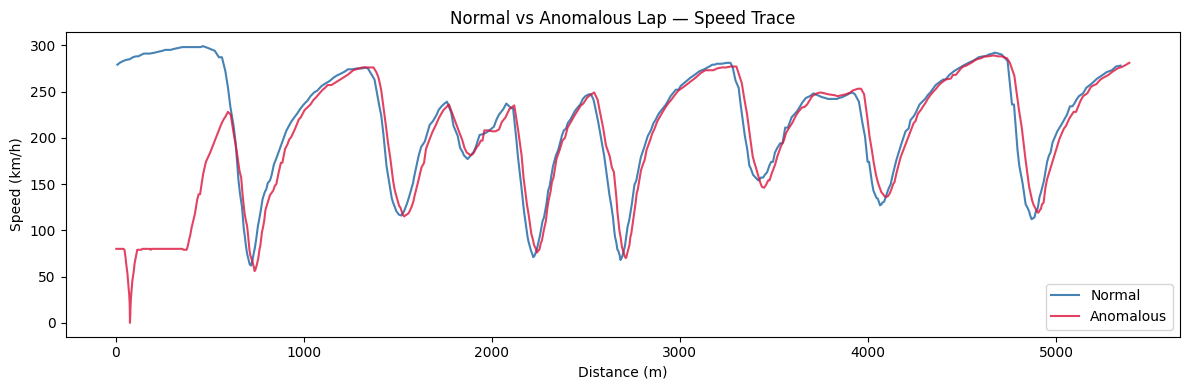

In [8]:
normal_lap = laps_clean[laps_clean['is_anomaly'] == False].iloc[10]
anomaly_lap = laps_clean[laps_clean['is_anomaly'] == True].iloc[0]

tel_normal = collector.get_telemetry(normal_lap)
tel_anomaly = collector.get_telemetry(anomaly_lap)

plt.figure(figsize=(12, 4))
plt.plot(tel_normal['Distance'], tel_normal['Speed'], label='Normal', color='steelblue')
plt.plot(tel_anomaly['Distance'], tel_anomaly['Speed'], label='Anomalous', color='crimson', alpha=0.8)
plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')
plt.title('Normal vs Anomalous Lap — Speed Trace')
plt.legend()
plt.tight_layout()
plt.show()